In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Sonal\Downloads\creditriskdataset\credit_risk_dataset.csv")

In [3]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [ ]:
# employement length can be null for students, self-employed people and people who are recently unemployed so we cannot drop
# these null values. Instead we will fill them with 0 to indicate that they dont have any empoloyement history.

In [ ]:
# for the loan_int_rate values should not be null because whenever a loan is taken interest rate is applied.
# these values can be null if status is waiting for approval or rejected applications.

In [7]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [ ]:
# 0 is fully paid and 1 is defaulted.

In [8]:
df['loan_grade'].value_counts()

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

In [ ]:
# A is very low interest low risk type of loan whereas g is high risk high interest loan

In [ ]:
# for the loan_int_rate we will check if null values are loans which are fully paid or defaulted.
# also since loan_grade states the the type of risk and interest if we have to fill these values we have to fill the values as per
# the classfication of interest rate and loan risk

In [11]:
df[df['loan_int_rate'].isnull()]['loan_grade'].value_counts()

loan_grade
B    1056
A    1003
C     630
D     312
E      83
F      27
G       5
Name: count, dtype: int64

In [12]:
df[df['loan_int_rate'].isnull()]['loan_status'].value_counts()

loan_status
0    2472
1     644
Name: count, dtype: int64

In [13]:
import plotly.express as px

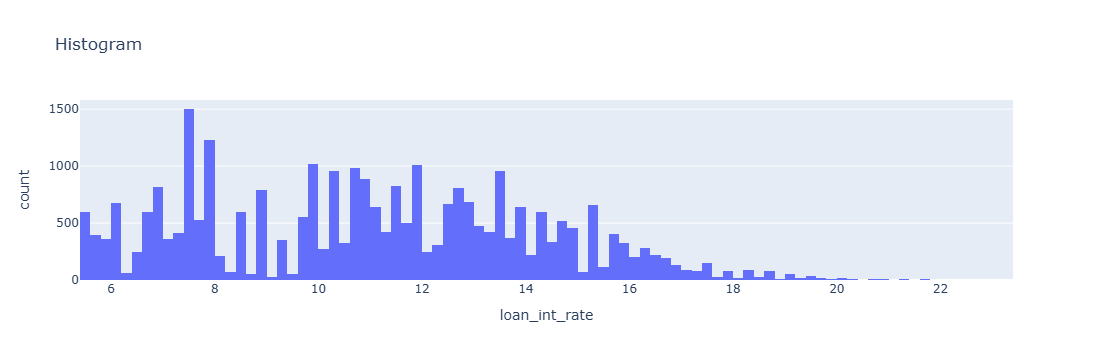

In [14]:
fig = px.histogram(
    df,
    x='loan_int_rate',
    title='Histogram'
)
fig.show()


In [ ]:
# the data is right skewed therefore we will use median of values to fill the null values based on the loan_grade
# we can use mean if the data is normally distributed but in this case it is not

In [15]:
# Filling null values in person_emp_length
df['person_emp_length'] = df['person_emp_length'].fillna(0)

In [18]:
df['person_emp_length'].isnull().sum()

np.int64(0)

In [19]:
# Filling null values in loan_int_rate
loan_rate_median = df.groupby('loan_grade')['loan_int_rate'].mean()
loan_rate_median

loan_grade
A     7.327651
B    10.995555
C    13.463542
D    15.361448
E    17.009455
F    18.609159
G    20.251525
Name: loan_int_rate, dtype: float64

In [22]:
# # Filling null values in loan_int_rate
df['loan_int_rate'] = df['loan_int_rate'].fillna(df.groupby('loan_grade')['loan_int_rate'].transform('median'))

In [23]:
df['loan_int_rate'].isnull().sum()

np.int64(0)

In [24]:
print(df['person_age'].describe())

count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64


In [26]:
# max age of a person is 144 which is unrealistic therefore we need to further investigate this column
# as per research banks give loan to people such that they are fully paid off till 60-70 years of their age
print(df[df['person_age']> 80].shape)

(7, 12)


In [27]:
df = df[df['person_age'] <= 80]

In [28]:
print(df['person_age'].describe())

count    32574.000000
mean        27.714281
std          6.186447
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max         80.000000
Name: person_age, dtype: float64


In [30]:
print(df['person_emp_length'].describe())

count    32574.000000
mean         4.658132
std          4.159792
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max        123.000000
Name: person_emp_length, dtype: float64


In [31]:
# employee cannot work more than they have lived
print(df[df['person_emp_length'] > 60].shape)

(2, 12)


In [32]:
df = df[df['person_emp_length'] <= 60]

In [33]:
print(df['person_emp_length'].describe())

count    32572.000000
mean         4.650866
std          4.055234
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max         41.000000
Name: person_emp_length, dtype: float64


In [35]:
print(df['person_income'].describe().round(2))

count      32572.00
mean       65878.88
std        52532.79
min         4000.00
25%        38500.00
50%        55000.00
75%        79200.00
max      2039784.00
Name: person_income, dtype: float64


In [41]:
df[df['person_income'] > 200_000]['loan_intent'].value_counts()


loan_intent
DEBTCONSOLIDATION    79
MEDICAL              79
PERSONAL             79
VENTURE              75
EDUCATION            70
HOMEIMPROVEMENT      63
Name: count, dtype: int64

In [42]:
df[df['person_income'] > 200_000]['loan_amnt'].describe()

count      445.000000
mean     17555.898876
std       9202.097341
min       1000.000000
25%      10000.000000
50%      16000.000000
75%      25000.000000
max      35000.000000
Name: loan_amnt, dtype: float64

In [43]:
# the loan amount taken is $35000 at max people earning more than $2,00,000 will not take such low loan 
df = df[df['person_income'] <= 200_000]

In [44]:
print(df[df['person_emp_length'] > 50].shape)
print(df[df['person_emp_length'] > 40].shape)

(0, 12)
(1, 12)


In [45]:
df = df[df['person_emp_length'] <= 40]

In [48]:
df.duplicated().sum()

np.int64(163)

In [49]:
# since duplicates in loan dataset means same loan is counted twice
df = df.drop_duplicates()

In [51]:
df.to_csv('credit_risk_clean.csv', index=False)
print(f"Final shape: {df.shape}")
print(f"Nulls remaining: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

Final shape: (31963, 12)
Nulls remaining: 0
Duplicates: 0
